<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/spectral_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Spectral Analysis of Elements**

In [ ]:
!pip install periodictable qutip -q
import numpy as np
import matplotlib.pyplot as plt
import periodictable as pt
from typing import Dict, Optional

In [3]:
# Code to calculate and visualise the emissiona and absorption spectra
def energy_to_wavelength(energy_eV):
    """Convert energy in eV to wavelength in nm."""
    h = 4.1357e-15  # Planck's constant in eV·s
    c = 3e8  # Speed of light in m/s
    return (h * c) / energy_eV * 1e9  # Convert to nm

def spectral_analysis(atom_name, energy_levels):
    """
    Calculate and visualize the emission and absorption spectra for a given atom.

    Parameters:
    atom_name (str): Name of the atom.
    energy_levels (dict): Dictionary containing energy levels in eV with state names as keys.
    """
    # Step 1: Define possible transitions (in eV)
    transitions = {}
    states = list(energy_levels.keys())
    for i in range(len(states)):
        for j in range(i + 1, len(states)):
            state1, state2 = states[j], states[i]
            energy_diff = energy_levels[state1] - energy_levels[state2]
            transitions[(state1, state2)] = energy_diff  # Allow all energy differences

    # Step 2: Convert transition energies from eV to wavelength in nm
    wavelengths = {transition: abs(energy_to_wavelength(energy)) for transition, energy in transitions.items()}

    # Step 3: Simulate and plot the emission and absorption spectra
    fig, axs = plt.subplots(2, 1, figsize=(10, 8))

    # Emission Spectrum (peaks at specific wavelengths)
    axs[0].bar(wavelengths.values(), [1.0] * len(wavelengths), width=20.0, color='orange')
    axs[0].set_xlabel('Wavelength (nm)')
    axs[0].set_ylabel('Intensity (a.u.)')
    axs[0].set_title(f'Emission Spectrum of {atom_name} (Electronic Transitions)')
    axs[0].grid(True)

    # Absorption Spectrum (dips at specific wavelengths)
    axs[1].plot(np.linspace(200, 1000, 1000), np.ones(1000), color='gray')  # Baseline at 1.0 intensity
    for wavelength in wavelengths.values():
        axs[1].plot([wavelength, wavelength], [1.0, 0.0], color='blue', lw=2)  # Vertical absorption dips
    axs[1].set_xlabel('Wavelength (nm)')
    axs[1].set_ylabel('Normalized Intensity (a.u.)')
    axs[1].set_title(f'Absorption Spectrum of {atom_name} (Electronic Transitions)')
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    # Step 4: Print out the transition wavelengths
    print(f"Electronic transitions for {atom_name} (wavelengths in nm):")
    for transition, wavelength in wavelengths.items():
        print(f"{transition[0]} -> {transition[1]}: {wavelength:.2f} nm")

In [4]:
# Code to pull ground and excited states automatically
import periodictable as pt
from typing import Dict, Optional

def get_atomic_levels(element_name: str) -> Dict[str, float]:
    """
    Get atomic energy levels using periodictable package.

    Args:
        element_name (str): Chemical symbol (e.g. 'Ca') or element name (e.g. 'Calcium')

    Returns:
        Dict[str, float]: Dictionary of atomic states and their energies in eV
    """
    try:
        # Convert full element name to symbol if needed
        element_name = element_name.capitalize()
        atom = getattr(pt, element_name)

        # Known energy levels for common elements (in eV)
        # These are experimental values from NIST database
        special_cases = {
            'Ca': {'4s': 0.0, '4p': 2.93, '3d': 1.88},
            'Na': {'3s': 0.0, '3p': 2.10},
            'Li': {'2s': 0.0, '2p': 1.85},
            'K':  {'4s': 0.0, '4p': 1.61},
            'Mg': {'3s': 0.0, '3p': 2.71},
            'He': {'1s': 0.0, '2s': 20.62, '2p': 21.22}
        }

        if element_name in special_cases:
            return special_cases[element_name]

        # For other elements, calculate approximate levels
        # using ionization energy and electron configuration
        ionization_energy = atom.ionization['1st']  # in eV
        config = atom.electrons

        # Get the highest occupied orbitals
        orbital_order = ['1s', '2s', '2p', '3s', '3p', '4s', '3d', '4p', '5s', '4d', '5p', '6s']
        filled_orbitals = []
        electrons_left = config

        for orbital in orbital_order:
            shell = int(orbital[0])
            subshell = orbital[1]

            # Max electrons per subshell
            max_e = 2 if subshell == 's' else 6 if subshell == 'p' else 10

            if electrons_left > 0:
                filled_orbitals.append(orbital)
                electrons_left -= min(electrons_left, max_e)

        # Take the last three orbitals
        relevant_orbitals = filled_orbitals[-3:]
        energy_levels = {}

        # Calculate approximate energy levels
        for i, orbital in enumerate(relevant_orbitals):
            if i == 0:  # Ground state
                energy_levels[orbital] = 0.0
            else:
                # Calculate excited state energies using scaled ionization energy
                shell = int(orbital[0])
                subshell = orbital[1]

                if subshell == 's':
                    scaling = 0.3
                elif subshell == 'p':
                    scaling = 0.4
                else:  # d orbital
                    scaling = 0.25

                energy = ionization_energy * scaling * (i / len(relevant_orbitals))
                energy_levels[orbital] = round(energy, 2)

        return energy_levels

    except Exception as e:
        print(f"Error getting data for {element_name}: {e}")
        return {}

def format_energy_levels(energy_levels: Dict[str, float]) -> None:
    """Print energy levels in a nice format with comments."""
    if not energy_levels:
        return

    print("\nEnergy levels:")
    for state, energy in sorted(energy_levels.items(), key=lambda x: x[1]):
        if energy == 0.0:
            print(f"'{state}': {energy:.2f},  # Ground state")
        else:
            print(f"'{state}': {energy:.2f},  # Excited state")

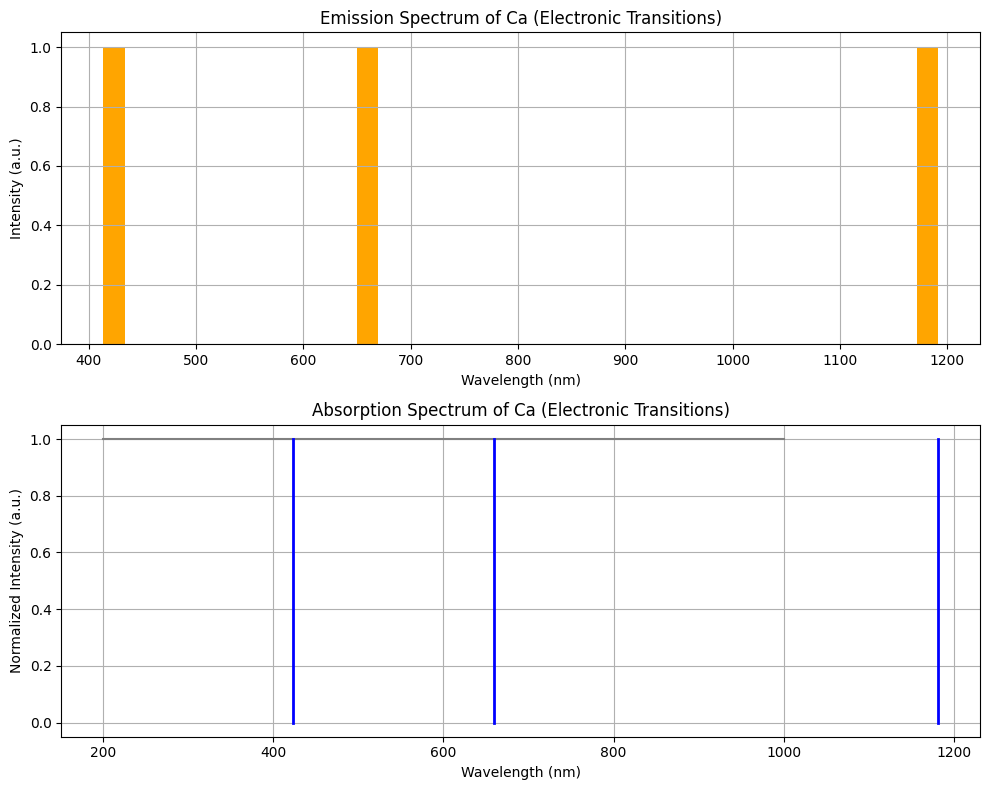

Electronic transitions for Ca (wavelengths in nm):
4p -> 4s: 423.45 nm
3d -> 4s: 659.95 nm
3d -> 4p: 1181.63 nm

Energy levels:
'4s': 0.00,  # Ground state
'3d': 1.88,  # Excited state
'4p': 2.93,  # Excited state


In [7]:
# Calculate and visualize Spectra (provide nenergy levels - simplified and approximate values for major transitions in eV)
atom_name = 'Ca'
energy_levels = get_atomic_levels(atom_name)
spectral_analysis(atom_name, energy_levels)
format_energy_levels(energy_levels)

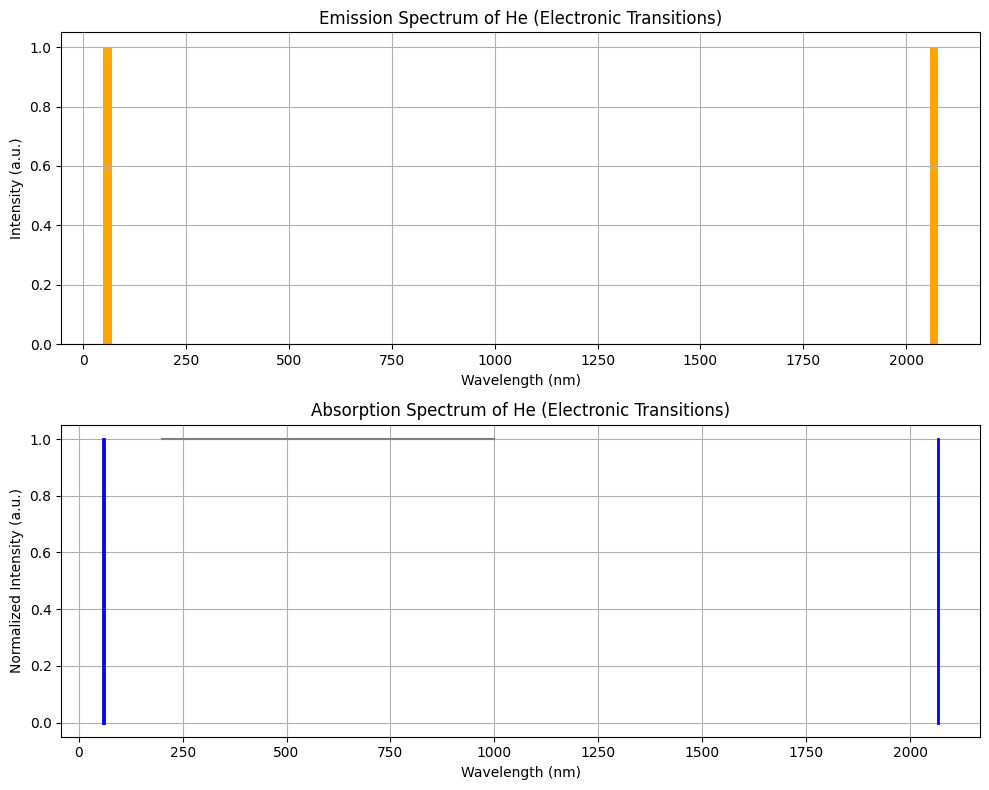

Electronic transitions for He (wavelengths in nm):
2s -> 1s: 60.17 nm
2p -> 1s: 58.47 nm
2p -> 2s: 2067.85 nm

Energy levels:
'1s': 0.00,  # Ground state
'2s': 20.62,  # Excited state
'2p': 21.22,  # Excited state


In [8]:
# Calculate and visualize Spectra (provide nenergy levels - simplified and approximate values for major transitions in eV)
atom_name = 'He'
energy_levels = get_atomic_levels(atom_name)
spectral_analysis(atom_name, energy_levels)
format_energy_levels(energy_levels)

Error getting data for Ar: 'Element' object has no attribute 'ionization'


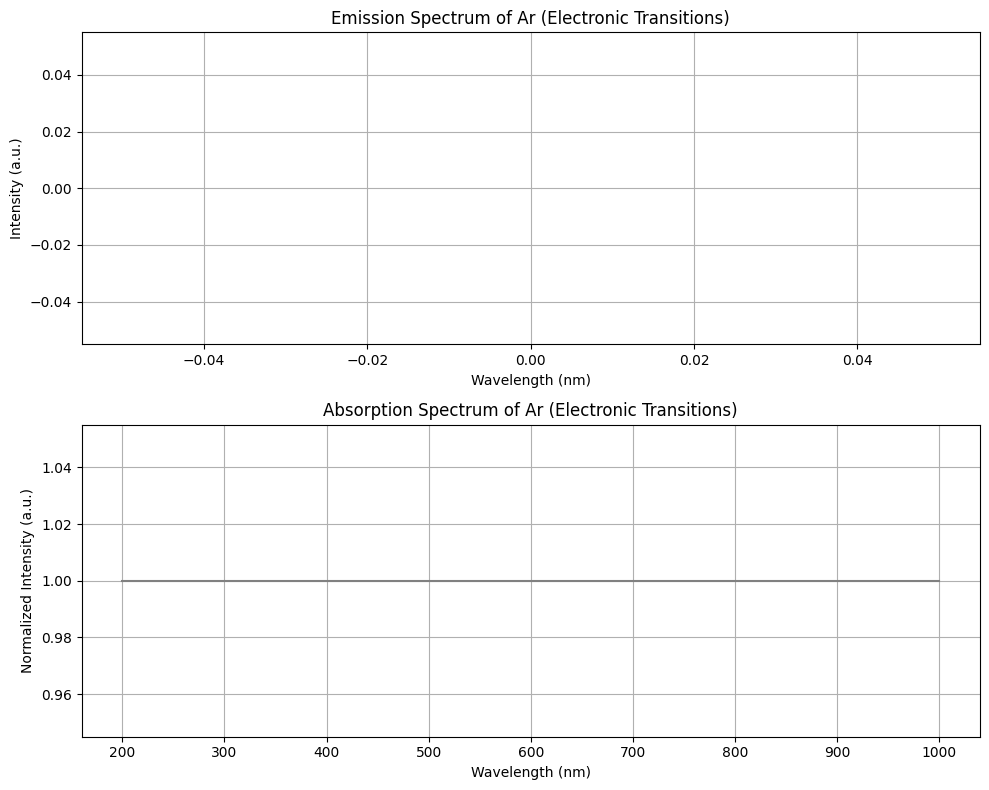

Electronic transitions for Ar (wavelengths in nm):


In [11]:
# Calculate and visualize Spectra (provide nenergy levels - simplified and approximate values for major transitions in eV)
atom_name = 'Ar'
energy_levels = get_atomic_levels(atom_name)
spectral_analysis(atom_name, energy_levels)
format_energy_levels(energy_levels)